# Задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом.
Постарайтесь сделать их как можно более похожими, и в тоже время различными.

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [56]:
# Игнорирование предупреждений
import warnings
warnings.simplefilter(action='ignore', category=['FutureWarning', 'RuntimeWarning'])


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом.
Постарайтесь сделать их как можно более похожими, и в тоже время различными.

In [3]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

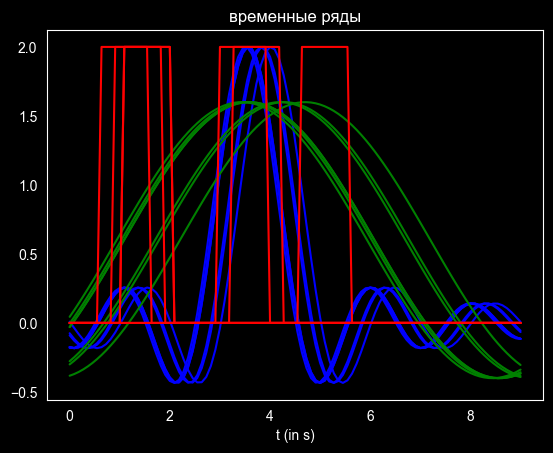

In [4]:
# индекс и отсчет времени в секундах
time_index = np.linspace(0, 9, 100)

tseries_list = {'Time': time_index}
d = np.random.random(size=10)


N = 7 #количество образцов в каждом типе сигналов


# гармонические колебания
f0 = 0.2

for i in range(N):
    tseries_list["Tc"+str(i)]= -np.cos(np.pi*f0*time_index + d[i]) + 0.6

# модифицированный синус
for i in range(N):
    tseries_list["Ts"+str(i)]= 2*np.sin(np.pi*time_index+ 2*d[i]-13) /(np.pi*time_index+ 2*d[i]-13)

# пульс сигнал
for i in range(N):
    tseries_list["Tp"+str(i)]= 2*pulse(time_index + 5*d[i] - 6)


# отрисовка всех сигналов
for i in range(N):
    plt.plot(time_index, tseries_list["Ts"+str(i)], '-b')
for i in range(N):
    plt.plot(time_index, tseries_list["Tc"+str(i)], '-g')
for i in range(N):
    plt.plot(time_index, tseries_list["Tp"+str(i)], '-r')

plt.title(r'временные ряды')
plt.xlabel(r't (in s)')
plt.grid()

In [5]:
tseries_list

{'Time': array([0.        , 0.09090909, 0.18181818, 0.27272727, 0.36363636,
        0.45454545, 0.54545455, 0.63636364, 0.72727273, 0.81818182,
        0.90909091, 1.        , 1.09090909, 1.18181818, 1.27272727,
        1.36363636, 1.45454545, 1.54545455, 1.63636364, 1.72727273,
        1.81818182, 1.90909091, 2.        , 2.09090909, 2.18181818,
        2.27272727, 2.36363636, 2.45454545, 2.54545455, 2.63636364,
        2.72727273, 2.81818182, 2.90909091, 3.        , 3.09090909,
        3.18181818, 3.27272727, 3.36363636, 3.45454545, 3.54545455,
        3.63636364, 3.72727273, 3.81818182, 3.90909091, 4.        ,
        4.09090909, 4.18181818, 4.27272727, 4.36363636, 4.45454545,
        4.54545455, 4.63636364, 4.72727273, 4.81818182, 4.90909091,
        5.        , 5.09090909, 5.18181818, 5.27272727, 5.36363636,
        5.45454545, 5.54545455, 5.63636364, 5.72727273, 5.81818182,
        5.90909091, 6.        , 6.09090909, 6.18181818, 6.27272727,
        6.36363636, 6.45454545, 6.545454

2. Рассчет расстояний по Евклиду и DTW

In [25]:
def Euclid(s1, s2):
    distance = np.zeros_like(s1)
    for i in range(len(s1)):
        distance[i] = np.sqrt((s1[i] - s2[i])**2)

    return distance

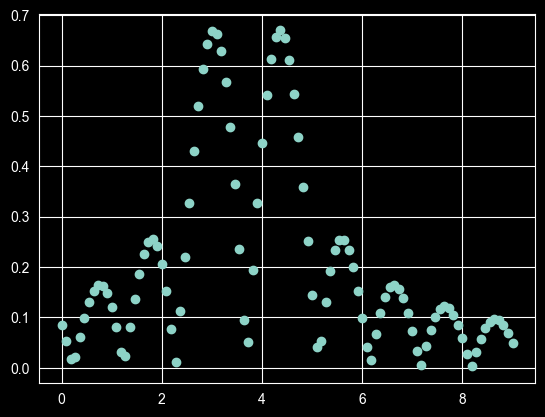

In [26]:
plt.scatter(x =tseries_list['Time'], y=Euclid(tseries_list['Ts1'], tseries_list['Ts2']))

Рассчет расстояний между времменными рядами с помощью Евклидова расстояния и DTW

In [36]:
from dtaidistance import dtw, dtw_visualisation as dtwvis


for i in tseries_list.keys():
    if i != 'Time':
        for j in tseries_list.keys():
            if j != 'Time' and j != i:
                x = np.abs(tseries_list[i])
                x_s = np.abs(tseries_list[j])


                distance_DTW, paths = dtw.warping_paths(x, x_s)
                distance_Euclid =  Euclid(x, x_s)
                print(f'The distance between {i} and {j}; DTW: {distance_DTW}, Euclid: {np.sum(distance_Euclid)}')

The distance between Tc0 and Tc1; DTW: 0.16458519671870814, Euclid: 5.796074039041121
The distance between Tc0 and Tc2; DTW: 0.386646582870647, Euclid: 28.213224415759953
The distance between Tc0 and Tc3; DTW: 0.4189983028061199, Euclid: 30.877336193530848
The distance between Tc0 and Tc4; DTW: 0.6864393744810694, Euclid: 43.61683048593036
The distance between Tc0 and Tc5; DTW: 0.1626000099518937, Euclid: 5.814195338015012
The distance between Tc0 and Tc6; DTW: 0.04619175044859415, Euclid: 3.706555951611011
The distance between Tc0 and Ts0; DTW: 1.574162967560661, Euclid: 48.074049884240644
The distance between Tc0 and Ts1; DTW: 1.581953664369463, Euclid: 48.10427103501394
The distance between Tc0 and Ts2; DTW: 1.6168572727687296, Euclid: 47.83689262010503
The distance between Tc0 and Ts3; DTW: 1.5936300534552077, Euclid: 47.570589129969186
The distance between Tc0 and Ts4; DTW: 1.5634453095762169, Euclid: 48.139370532076924
The distance between Tc0 and Ts5; DTW: 1.5819827138722222, Eu

## 3. Краткие выводы

DTW расстояния внутри одного класса (Ts) значительно меньше (0.002-0.54), чем между разными классами (Tc: 1.30-1.61, Tp: 2.98-3.00), при этом евклидова метрика показывает менее четкое разделение, что подтверждает эффективность DTW для классификации временных рядов с учетом временных сдвигов.

## 4. Формируем наборы для обучения

In [37]:
# переделываем датасет так, чтобы с ним можно было бы работать

x = []  #значения
Y = []  # целевая переменная

for v in tseries_list:
    if v!= 'Time':
        x.append(tseries_list[v])
        c = v[:-1]
        if c == "Ts":
            Y.append(0)
        elif c == "Tc":
            Y.append(1)
        else: Y.append(2)


arr = np.arange(len(Y))
np.random.shuffle(arr)


print(Y)
print(x)

X_train = []
X_test = []
y_train = []
y_test = []

for i in arr[:-5]:
    X_train.append(x[i])
    y_train.append(Y[i])

for i in arr[len(X_train):]:
    X_test.append(x[i])
    y_test.append(Y[i])


[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2]
[array([ 0.04439376,  0.09276613,  0.142793  ,  0.19431118,  0.24715263,
        0.301145  ,  0.35611217,  0.41187485,  0.46825115,  0.5250572 ,
        0.58210769,  0.63921654,  0.69619748,  0.75286464,  0.80903319,
        0.86451991,  0.91914383,  0.97272676,  1.02509394,  1.07607455,
        1.1255023 ,  1.17321598,  1.21905994,  1.26288466,  1.30454718,
        1.34391162,  1.38084958,  1.41524056,  1.4469724 ,  1.47594159,
        1.50205365,  1.52522339,  1.54537524,  1.56244348,  1.57637243,
        1.58711665,  1.5946411 ,  1.59892124,  1.59994311,  1.59770337,
        1.59220933,  1.58347891,  1.57154059,  1.5564333 ,  1.53820632,
        1.51691912,  1.49264111,  1.46545149,  1.43543895,  1.40270138,
        1.36734556,  1.32948683,  1.28924866,  1.2467623 ,  1.20216634,
        1.15560624,  1.10723387,  1.057207  ,  1.00568882,  0.95284737,
        0.898855  ,  0.84388783,  0.78812515,  0.73174885,  0.6749428 ,

## 5.1 KNN с DTW

In [53]:
from pyts.classification import KNeighborsClassifier

clf = KNeighborsClassifier(metric='dtw')
clf.fit(X_train, y_train)

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 1.0
Вектор вероятности принадлежности к классам [[0. 0. 1.]]
Истинный класс для предсказаний 2


In [60]:
from pyts.classification import KNeighborsClassifier

clf = KNeighborsClassifier(metric='minkowski')
clf.fit(X_train, y_train)

print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")

Accuracy 0.8


TypeError: issubclass() arg 2 must be a class, a tuple of classes, or a union

In [49]:
import numpy as np
from pyts.classification import TimeSeriesForest

clf = TimeSeriesForest(random_state=12)
clf.fit(X_train, y_train)


print(f"Accuracy {clf.score(X_test, y_test)}")
print(f"Вектор вероятности принадлежности к классам {clf.predict_proba(X_test[2].reshape(1, -1))}")
print(f"Истинный класс для предсказаний {y_test[2]}")


Accuracy 1.0
Вектор вероятности принадлежности к классам [[0.032 0.034 0.934]]
Истинный класс для предсказаний 2


## Выводы

В ходе экспериментов наилучшие результаты показали модели kNN с DTW метрикой и TimeSeriesForest, достигнув 100% точности классификации, при этом использование стандартной евклидовой метрики снизило точность kNN до 80%, что подтверждает важность учёта временных сдвигов в данных. Все модели уверенно определили тестовый образец как принадлежащий к классу 2, причём kNN с DTW продемонстрировал максимальную уверенность предсказания.